In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

import seaborn as sns
from helper_functions_objs import *

## Pre-process the objective values

In [5]:
obj_names = ['REL', 'RF', 'INPC', 'PFC', 'WCC']
util_abbrevs = ['W', 'D', 'F']

# append obj names to util_abbrevs
objs_utils = [f'{obj}_{util}' for util in util_abbrevs for obj in obj_names]
objs_regional =  [f'{obj}_R' for obj in obj_names]
objs_W = [f'{obj}_W' for obj in obj_names]
objs_D = [f'{obj}_D' for obj in obj_names]
objs_F = [f'{obj}_F' for obj in obj_names]
util_dict = {'W':'Watertown', 'D':'Dryville', 'F':'Fallsland'}

In [6]:
obj_mode = 'p10'

# read in objectives
objs_truncated_base_allutils = pd.read_csv(f'objectives_dvs_nd/objectives_base_{obj_mode}_nd.csv', index_col=False, header=None)
objs_truncated_base_allutils.columns = objs_utils
objs_truncated_IU_allutils = pd.read_csv(f'objectives_dvs_nd/objectives_IU_{obj_mode}_nd.csv', index_col=False, header=None)
objs_truncated_IU_allutils.columns = objs_utils

# split objectives by utility
objs_W_IU = objs_truncated_IU_allutils[[f'{obj}_W' for obj in obj_names]]
objs_D_IU = objs_truncated_IU_allutils[[f'{obj}_D' for obj in obj_names]]
objs_F_IU = objs_truncated_IU_allutils[[f'{obj}_F' for obj in obj_names]]

objs_W_base = objs_truncated_base_allutils[[f'{obj}_W' for obj in obj_names]]
objs_D_base = objs_truncated_base_allutils[[f'{obj}_D' for obj in obj_names]]
objs_F_base = objs_truncated_base_allutils[[f'{obj}_F' for obj in obj_names]]

# find regional minimax solutions
objs_reg_base = find_regional_minimax(objs_truncated_base_allutils, obj_names)
objs_reg_IU = find_regional_minimax(objs_truncated_IU_allutils, obj_names)

# combine regional with main set of objectives 
objs_IU_all = pd.concat([objs_truncated_IU_allutils, objs_reg_IU], axis=1)
objs_base_all = pd.concat([objs_truncated_base_allutils, objs_reg_base], axis=1)

In [8]:
'''
'base-pw': sim_mode_colors_base.get('base-pw', "#8FCCAE"),
    'base-sp': sim_mode_colors_base.get('base-sp', '#307351') 

sols_to_highlight = {"base_sp_deg25": [31],
                     "base_sp": [40],
                     "social_planner_IU": [499],
                     "power_index_IU": [7]}
'''
# solutions of interest
social_planner_IU = 401
power_index_IU = 61
baseline = 29
#social_planner_IU = 552
#power_index_IU = 260
#baseline = 29

sim_mode_colors_coop = {'baseline': "#39563D",
                            'power index': "#F5AB23", 'social planner': "#B66D0D"}

sols_to_highlight = {"baseline": [baseline],
                     "power index": [power_index_IU], "social planner": [social_planner_IU]}

sim_mode_colors_IU = {'others': 'gainsboro','power index': "#FAC268", 'social planner': "#B66D0D"}
sim_mode_colors_base = {'others': 'gainsboro', 'baseline': "#39563D"}

# high_coop_sols 
social_planner_IU_df = pd.DataFrame(objs_IU_all.loc[[social_planner_IU]].values, columns=objs_IU_all.columns)
power_index_IU_df = pd.DataFrame(objs_IU_all.loc[[power_index_IU]].values, columns=objs_IU_all.columns)
baseline_df = pd.DataFrame(objs_base_all.loc[[baseline]].values, columns=objs_base_all.columns)

# categorized objectives 
objs_IU_all_cat = objs_IU_all.copy()
objs_IU_all_cat['Category'] = 'others'
social_planner_IU_df['Category'] = 'social planner'
power_index_IU_df['Category'] = 'power index'
objs_IU_all_cat = pd.concat([objs_IU_all_cat, social_planner_IU_df, power_index_IU_df], axis=0, ignore_index=True)

objs_base_all_cat = objs_base_all.copy()
objs_base_all_cat['Category'] = 'others'
baseline_df['Category'] = 'baseline'
objs_base_all_cat = pd.concat([objs_base_all_cat, baseline_df], axis=0, ignore_index=True)

## Plot the parallel coordinate plots of the regional tradeoff set

In [9]:
from matplotlib import colormaps, cm
from matplotlib.collections import PatchCollection
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
from pandas.plotting import parallel_coordinates
from parallel_plot_functions import *

In [28]:
util_selected = 'W'
#cols_to_plot = objs_W + ['Category']
cols_to_plot = [f'REL_{util_selected}', f'RF_{util_selected}', f'INPC_{util_selected}', f'PFC_{util_selected}', f'WCC_{util_selected}'] + ['Category']

objs_IU_to_plot = objs_IU_all_cat[cols_to_plot]
objs_base_to_plot = objs_base_all_cat[cols_to_plot]

color_dict = sim_mode_colors_IU
# setup figure specifications and dimensions
figsize = (9,4)
fontsize = 14
'''
axis_mins = np.min([objs_IU_to_plot.min().values[:-1] - (objs_IU_to_plot.min().values[:-1]*0.05), 
                    objs_base_to_plot.min().values[:-1] - (objs_base_to_plot.min().values[:-1]*0.05)], axis=0)
axis_maxs = np.max([objs_IU_to_plot.max().values[:-1] + (objs_IU_to_plot.max().values[:-1]*0.05), 
                    objs_base_to_plot.max().values[:-1] + (objs_base_to_plot.max().values[:-1]*0.05)], axis=0)

# cap axis mins and maxs to reasonable values
axis_mins = np.maximum(axis_mins, 0.0)
axis_maxs[0] = min(axis_maxs[0], 1.0)
'''

axis_mins_dict = {'avg': [0.95, 0.0, 0.0,0.0,0.0], 'p10': [0.85, 0.0, 0.0,0.0,0.0]}
axis_maxs_dict = {'avg': [1.0, 0.3, 150.0, 0.25, 0.25], 'p10': [1.0, 0.7, 350.0, 0.5, 0.7]}
axis_mins = axis_mins_dict[obj_mode]
axis_maxs = axis_maxs_dict[obj_mode]
#axis_mins = [0.95, 0.0, 0.0,0.0,0.0]
#axis_maxs = [1.0, 0.3, 125.0, 0.25, 0.2]
# get the axis labels 
axis_labels = objs_IU_to_plot.columns.tolist()[:-1]

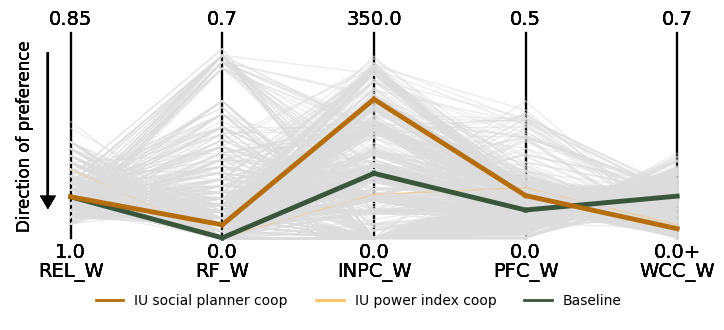

In [29]:
### create figure
fig, ax = plt.subplots(1,1,figsize=figsize, gridspec_kw={'hspace':0.1, 'wspace':0.1})

# all IU solutions in the background
custom_parallel_coordinates(fig, ax, objs_IU_to_plot, columns_axes=axis_labels, 
                                axis_labels=axis_labels, 
                                ideal_direction='bottom',
                                alpha_base=0.5, lw_base=1, fontsize=fontsize,
                                minmaxs=['max','min','min','min','min'], 
                                colorbar_ticks_continuous=range(0,1,5),
                                color_by_categorical = 'Category', 
                                color_dict_categorical=sim_mode_colors_IU,
                                axis_mins=axis_mins, axis_maxs=axis_maxs)
# all baseline solutions in the background
custom_parallel_coordinates(fig, ax, objs_base_to_plot, columns_axes=axis_labels, 
                                axis_labels=axis_labels, 
                                ideal_direction='bottom',
                                alpha_base=0.5, lw_base=1, fontsize=fontsize,
                                minmaxs=['max','min','min','min','min'], 
                                colorbar_ticks_continuous=range(0,1,5),
                                color_by_categorical = 'Category', 
                                color_dict_categorical=sim_mode_colors_base,
                                axis_mins=axis_mins, axis_maxs=axis_maxs) 
'''
custom_parallel_coordinates(fig, ax, base_sp_df, columns_axes=axis_labels, 
                                axis_labels=axis_labels, 
                                ideal_direction='bottom',
                                alpha_base=1.0, lw_base=3.5, fontsize=fontsize,
                                minmaxs=['max','min','min','min','min'], 
                                colorbar_ticks_continuous=range(0,1,5),
                                color_by_categorical = 'Category', 
                                color_dict_categorical=sim_mode_colors_base,
                                axis_mins=axis_mins, axis_maxs=axis_maxs) 

# solution 129 from the IU reference set
custom_parallel_coordinates(fig, ax, power_index_IU_df, columns_axes=axis_labels, 
                                axis_labels=axis_labels, 
                                ideal_direction='bottom',
                                alpha_base=1.0, lw_base=3.5, fontsize=fontsize,
                                minmaxs=['max','min','min','min','min'], 
                                colorbar_ticks_continuous=range(0,1,5),
                                color_by_categorical = 'Category', 
                                color_dict_categorical=sim_mode_colors_IU,
                                axis_mins=axis_mins, axis_maxs=axis_maxs) 
'''
custom_parallel_coordinates(fig, ax, baseline_df, columns_axes=axis_labels, 
                                axis_labels=axis_labels, 
                                ideal_direction='bottom',
                                alpha_base=1.0, lw_base=3.5, fontsize=fontsize,
                                minmaxs=['max','min','min','min','min'], 
                                colorbar_ticks_continuous=range(0,1,5),
                                color_by_categorical = 'Category', 
                                color_dict_categorical=sim_mode_colors_base,
                                axis_mins=axis_mins, axis_maxs=axis_maxs) 

# solution 407 from the IU reference set
custom_parallel_coordinates(fig, ax, social_planner_IU_df, columns_axes=axis_labels, 
                                axis_labels=axis_labels, 
                                ideal_direction='bottom',
                                alpha_base=1.0, lw_base=3.5, fontsize=fontsize,
                                minmaxs=['max','min','min','min','min'], 
                                colorbar_ticks_continuous=range(0,1,5),
                                color_by_categorical = 'Category', 
                                color_dict_categorical=sim_mode_colors_IU,
                                axis_mins=axis_mins, axis_maxs=axis_maxs) 

# create a legend 
handles = [Line2D([0], [0], color=sim_mode_colors_IU['social planner'], lw=2, label='IU social planner coop'),
           Line2D([0], [0], color=sim_mode_colors_IU['power index'], lw=2, label='IU power index coop'),
              Line2D([0], [0], color=sim_mode_colors_base['baseline'], lw=2, label='Baseline')]
plt.legend(handles=handles, loc='lower center', fontsize=fontsize-4, frameon=False, bbox_to_anchor=(0.5, 0.0), ncols=5)
#ax.set_title(f'IU and baseline selected solution tradeoffs', fontsize=fontsize+2, pad=20)
#ax.set_title(f"{util_dict[util_selected]} high-cooperation solutions performance tradeoffs", fontsize=fontsize+2, pad=20)
plt.savefig(f'figures/parallel_IUbase_regional_{util_selected}_limWCC_{obj_mode}.pdf', dpi=300, bbox_inches='tight')
plt.show()

## Explore decision variables 

In [5]:
# create decision variable files with headers 
dv_names = ['RT_W', 'RT_D', 'RT_F', 'TT_D', 'TT_F', 'LMA_W', 'LMA_D', 'LMA_F', \
    'AP_W', 'AP_D', 'AP_F', 'IT_W', 'IT_D', 'IT_F', 'IP_W', 'IP_D', 'IP_F', \
    'INF_W', 'INF_D', 'INF_F', 'NRR_W', 'CRL', 'CRH', 'WR1', 'SCR', 'GQR', \
    'NRR_F', 'WR2_W', 'WR2_D', 'WR2_F']

dv_base_filename = 'objectives_dvs_nd/dvs_base_nd_truncated_extremes.csv'
dv_iu_filename = 'objectives_dvs_nd/dvs_IU_nd_truncated_extremes.csv'

trigger_names = ['RT_W', 'RT_D', 'RT_F', 'TT_D', 'TT_F','INF_W', 'INF_D', 'INF_F']
alloc_names = ['LMA_W', 'LMA_D', 'LMA_F', 'AP_W', 'AP_D', 'AP_F']
dvs_relevant = trigger_names + alloc_names
infra_W = ['NRR_W', 'CRL', 'CRH', 'WR1', 'GQR', 'WR2_W']
infra_D = ['SCR', 'WR2_D']
infra_F = ['NRR_F', 'WR2_F']

util_abbrevs = ['W', 'D', 'F']
util_names_dict = {'W': 'Watertown', 'D': 'Dryville', 'F': 'Fallsland'}

num_dvs = len(dv_names)
# import decision variable files 
dv_iu = pd.read_csv(dv_iu_filename, index_col=None, header=None)
dv_base = pd.read_csv(dv_base_filename, index_col=None, header=None)

# replace column headers with abbreviated names
dv_iu.columns = dv_names
dv_base.columns = dv_names

dv_IU_triggers = dv_iu[trigger_names]
dv_base_triggers = dv_base[trigger_names]
dvs_base_relevant = dv_base[dvs_relevant]
dvs_IU_relevant = dv_iu[dvs_relevant]
infra_W_triggers_IU = dv_iu[infra_W]
infra_D_triggers_IU = dv_iu[infra_D]   
infra_F_triggers_IU = dv_iu[infra_F]
infra_W_triggers_base = dv_base[infra_W]
infra_D_triggers_base = dv_base[infra_D]
infra_F_triggers_base = dv_base[infra_F]

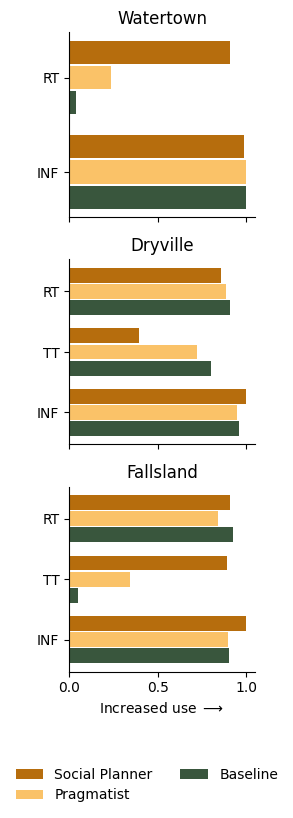

In [25]:
# Utilities and triggers (Watertown only has RT and INF as requested)
utils = ['W', 'D', 'F']
utils_dict = {'W': 'Watertown', 'D': 'Dryville', 'F': 'Fallsland'}
triggers_per_util = {
    'W': ['RT_W', 'INF_W'],
    'D': ['RT_D', 'TT_D', 'INF_D'],
    'F': ['RT_F', 'TT_F', 'INF_F'],
}

# Solutions to plot: baseline + IU high-coop solutions
#base_idx = base_sp[0]            # e.g., 36

solutions = [
    ('Social Planner', 552),
    ('Pragmatist', 260),
    ('Baseline', 43),
]
'''
solutions = [
    ('Social Planner', 552),
    ('Pragmatist', 260),
    ('Baseline', 29),
]
'''
# Colors: use your color dicts already defined in the notebook
color_map = {
    'Pragmatist': sim_mode_colors_IU.get('power index', "#F5C372"),
    'Social Planner': sim_mode_colors_IU.get('social planner', '#B66D0D'),
    'Baseline': sim_mode_colors_base.get('baseline', "#425E46")
}
    

# Figure & axes
fig, axs = plt.subplots(len(utils), 1, figsize=(2.5, 8), sharex=True)
axs = axs.flatten() if isinstance(axs, np.ndarray) else [axs]
if not isinstance(axs, (list, np.ndarray)):
    axs = [axs]

for i, util in enumerate(utils):
    ax = axs[i]
    triggers = triggers_per_util[util]
    n_tr = len(triggers)
    n_sol = len(solutions)

    # y positions = one row per trigger; we'll offset bars for each solution inside each group
    y = np.arange(n_tr)
    total_group_height = 0.8
    bar_height = total_group_height / n_sol
    offsets = (np.arange(n_sol) - (n_sol - 1) / 2.0) * bar_height

    # Plot each solution (one set of bars per solution)
    for j, (label, sol_idx) in enumerate(solutions):
        vals = []
        for t in triggers:
            if label == 'baseline':
                raw = dv_base_triggers.iloc[sol_idx][t]
            else:
                raw = dv_IU_triggers.iloc[sol_idx][t]
            v = 1.0 - raw             # keep original 1.0 - dv logic

            vals.append(v)

        y_pos = y + offsets[j]
        ax.barh(y_pos, vals, height=bar_height * 0.92, color=color_map.get(label, 'lightgrey'), label=label)

    # labels and style
    ax.set_yticks(y)
    ax.set_yticklabels([t.split('_')[0] for t in triggers])
    ax.set_title(utils_dict[util])
    if i == len(utils) - 1:
        ax.set_xlabel(r"Increased use $\longrightarrow$")
    ax.invert_yaxis()  # optional: put first trigger at top; remove if you prefer bottom-up
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Shared legend below
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.025))
fig.tight_layout(rect=[0, 0.08, 1, 1])
# Save/show
plt.savefig('../../../Paper 3/figures/grouped_selected_solutions_byutil_p3.jpg', dpi=300, bbox_inches='tight')
plt.show()

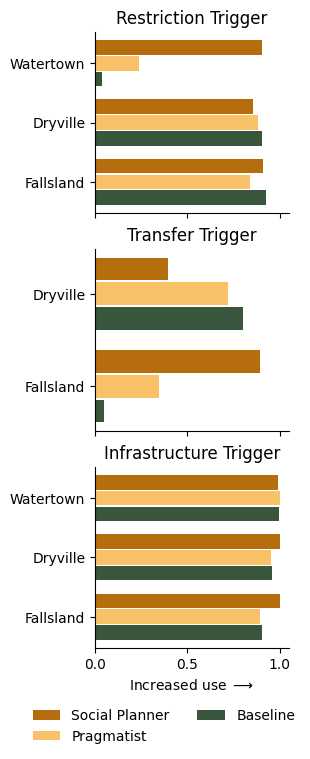

In [24]:
# Define the three triggers to plot
triggers_to_plot = ['RT', 'TT', 'INF']
triggers_to_title = {'RT': 'Restriction Trigger', 'TT': 'Transfer Trigger', 'INF': 'Infrastructure Trigger'}
# Figure & axes - one subplot per trigger type
fig, axs = plt.subplots(len(triggers_to_plot), 1, figsize=(2.5, 8), sharex=True)
axs = axs.flatten() if isinstance(axs, np.ndarray) else [axs]
if not isinstance(axs, (list, np.ndarray)):
    axs = [axs]

for i, trigger_prefix in enumerate(triggers_to_plot):
    ax = axs[i]
    
    # Find which utilities have this trigger type
    relevant_utils = []
    trigger_names = []
    for util in utils:
        # Find triggers for this utility that match the prefix
        matching_triggers = [t for t in triggers_per_util[util] if t.startswith(trigger_prefix)]
        if matching_triggers:
            relevant_utils.append(util)
            trigger_names.append(matching_triggers[0])  # Use the first matching trigger
    
    n_util = len(relevant_utils)
    n_sol = len(solutions)
    
    # y positions = one row per utility
    y = np.arange(n_util)
    total_group_height = 0.8
    bar_height = total_group_height / n_sol
    offsets = (np.arange(n_sol) - (n_sol - 1) / 2.0) * bar_height
    
    # Plot each solution
    for j, (label, sol_idx) in enumerate(solutions):
        vals = []
        for trigger_name in trigger_names:
            if label == 'baseline':
                raw = dv_base_triggers.iloc[sol_idx][trigger_name]
            else:
                raw = dv_IU_triggers.iloc[sol_idx][trigger_name]
            v = 1.0 - raw
            vals.append(v)
        
        y_pos = y + offsets[j]
        ax.barh(y_pos, vals, height=bar_height * 0.92, color=color_map.get(label, 'lightgrey'), label=label)
    
    # Labels and style
    ax.set_yticks(y)
    ax.set_yticklabels([utils_dict[util] for util in relevant_utils])
    ax.set_title(triggers_to_title.get(trigger_prefix, trigger_prefix))  # RT, TT, or INF as title
    if i == 2:
        ax.set_xlabel(r"Increased use $\longrightarrow$")
    ax.invert_yaxis()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Shared legend below
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, frameon=False, bbox_to_anchor=(0.4, -0.025))
plt.savefig('../../../Paper 3/figures/grouped_selected_solutions_bytrigger_p3.pdf', dpi=300, bbox_inches='tight')
plt.show()

### Decision variable polar plots 

In [ ]:
def plot_polar_selected_dvs(dvs_sol_selected, dvs_sol_color_list, sol_name_list, utility, dv_names_util, ax):
    # get the first letter of the utility name
    util_abbrev = utility[0]

    dv_names_u = [f'{d}_{util_abbrev}' for d in dv_names_util]
    dv_names_u_buffer = [''] + [f'{d}_{util_abbrev}' for d in dv_names_util] + ['']

    # create a list of trigger names if the dv name contains T 
    dv_triggers_idx = [c for c in dv_names_u if ('T' in c or 'INF' in c)]
    
    dv_triggers = 1 - dvs_sol_selected.loc[:,dv_triggers_idx].values
    dv_triggers_buffer = np.zeros((dv_triggers.shape[0], dv_triggers.shape[1]+2))
    dv_triggers_buffer[:, 1:-1] = dv_triggers
    
    # plot the buffered dvs
    dv_toplot_arr = dv_triggers_buffer

    # plot each decision variable on the polar plot 
    theta = np.linspace(0, np.pi, dv_toplot_arr.shape[1])
    theta[1] = (np.pi/dv_toplot_arr.shape[1]) - (np.pi/dv_toplot_arr.shape[1]*0.25)
    if len(dv_names_u) == 2:
        theta[2] = np.pi - (np.pi/dv_toplot_arr.shape[1]*0.75)
    else:
        theta[len(dv_names_u)] = (4*np.pi/dv_toplot_arr.shape[1]) + (np.pi/dv_toplot_arr.shape[1]*0.25)

    for j in range(0, dvs_sol_selected.shape[0]):
        if utility == 'Watertown':
            if sol_name_list[j] == 'Baseline':
                # plot as points only
                ax.scatter(theta - 0.12, dv_toplot_arr[j,:], color=dvs_sol_color_list[j], s=90, 
                           zorder=800, linewidth=2, edgecolor='#30595A', label=sol_name_list[j])
            else:
                ax.bar(theta - (j%3)*0.12, dv_toplot_arr[j,:], color=dvs_sol_color_list[j], 
                    label=sol_name_list[j], width=0.12, bottom=0.0, zorder=700)
            
        else:
            if sol_name_list[j] == 'Baseline':
                # plot as points only
                ax.scatter(theta - 0.12, dv_toplot_arr[j,:], color=dvs_sol_color_list[j], s=90, 
                           zorder=800, linewidth=2, edgecolor="#30595A")
            else:
                ax.bar(theta - (j%3)*0.12, dv_toplot_arr[j,:], color=dvs_sol_color_list[j], 
                    width=0.12, bottom=0.0, zorder=700)
    
    # Set half-moon (0 to pi) limits
    ax.set_thetagrids(range(0, 180, int(180/len(dv_names_u))), (dv_names_u))
    ax.set_thetamin(0)
    ax.set_thetamax(180)
    ax.set_xticks(theta, dv_names_u_buffer)
    ax.set_xticklabels(dv_names_u_buffer, fontsize=12)
    ax.set_yticklabels([])
    ax.set_title(f'{utility} DVs', fontsize=14, pad=-5)

    # make the radial gridlines invisible
    ax.yaxis.grid(True, color='gainsboro', linestyle='--')
    ax.xaxis.grid(False)
    # remove the polar spine
    ax.spines['polar'].set_visible(False)